In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from manify.manifolds import ProductManifold

In [30]:
# Hyperparameters
CURVATURE = -1
DIMENSION = 2
N_SAMPLES = 100

X shape: torch.Size([100, 3])
Dists shape: torch.Size([100, 100])


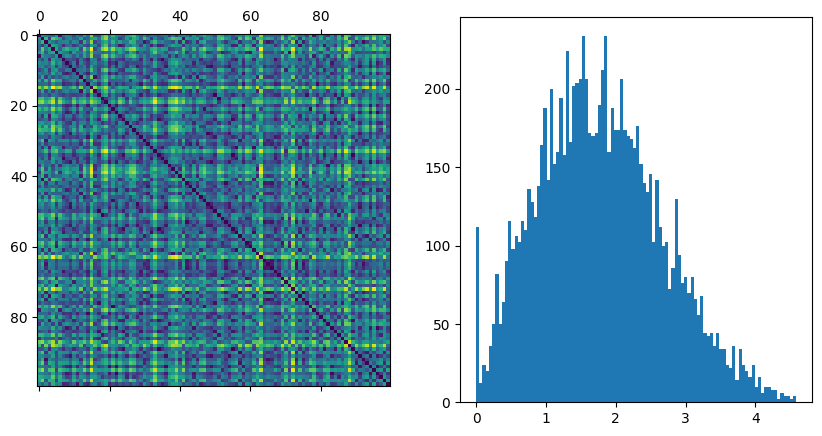

In [31]:
pm = ProductManifold(signature=[(CURVATURE, DIMENSION)])
X, _ = pm.sample(z_mean=torch.stack([pm.mu0] * N_SAMPLES))
print(f"X shape: {X.shape}")

# Get distances
dists = pm.pdist(X)
print(f"Dists shape: {dists.shape}")

# What is the distribution of pairwise distances?
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].matshow(dists.detach().cpu().numpy())
axs[1].hist(dists.detach().cpu().numpy().flatten(), bins=100)
plt.show()

Deltas shape: torch.Size([100, 100, 100])
Max delta: 3.77662992477417
Ground Delta: 0.27794119715690613


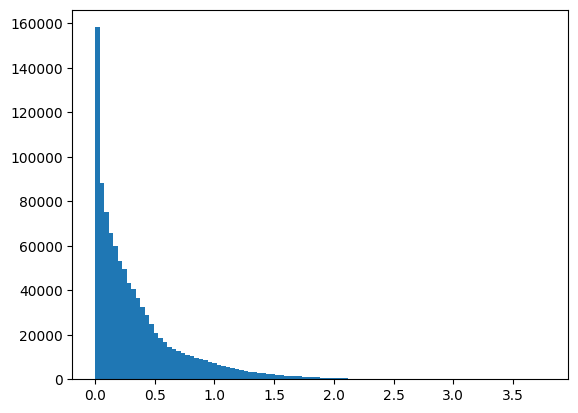

In [32]:
# What is the distribution of deltas?
from manify.curvature_estimation.delta_hyperbolicity import (
    delta_hyperbolicity,
    delta_full,
)

D_FUNC = delta_full

deltas = D_FUNC(dists)
delta_actual = delta_hyperbolicity(dists)
print(f"Deltas shape: {deltas.shape}")  # TODO: this should be N x N x N, I believe - we need to find the other N
print(f"Max delta: {deltas.max().item()}")
print(f'Ground Delta: {delta_actual}')

plt.hist(deltas.detach().cpu().numpy().flatten(), bins=100)
plt.show()

Curvature: -3.0, actual delta: 0.13181573152542114
Curvature: -2.5, actual delta: 0.1433669924736023
Curvature: -2.0, actual delta: 0.1577509045600891
Curvature: -1.5, actual delta: 0.17414796352386475
Curvature: -1.0, actual delta: 0.19990190863609314
Curvature: -0.5, actual delta: 0.24502679705619812
Curvature: 0.0, actual delta: 0.33085644245147705
h_Delta max: 1.0087603330612183
h_Delta max: 1.0087366104125977
h_Delta max: 1.0088809728622437
h_Delta max: 1.0093311071395874
h_Delta max: 1.0104378461837769
h_Delta max: 1.013437032699585
h_Delta max: 1.0278924703598022
E_Delta max: 1.8494594097137451
E_Delta max: 1.8217285871505737
E_Delta max: 1.7842657566070557
E_Delta max: 1.7302052974700928
E_Delta max: 1.6438403129577637
E_Delta max: 1.4799365997314453
E_Delta max: 1.0278927087783813


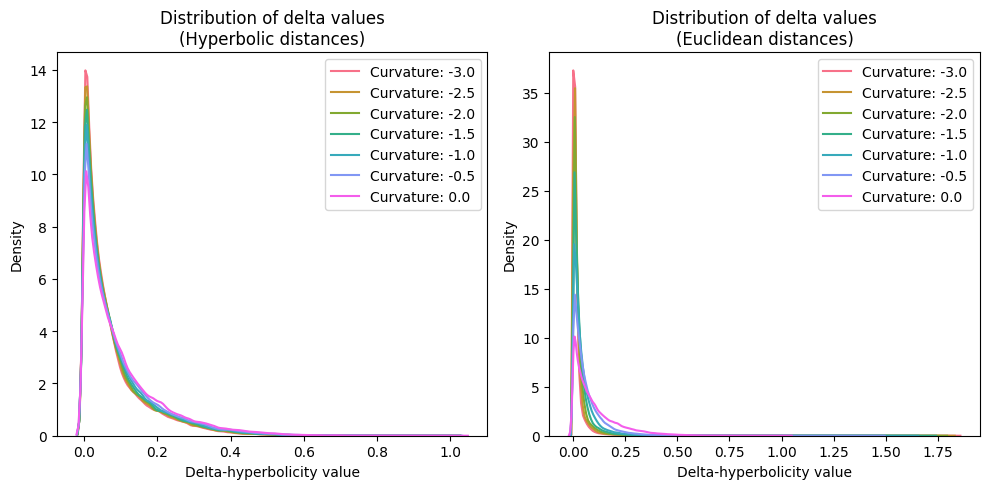

In [55]:
# Experiment 1: How does delta change with curvature?

import seaborn as sns
import numpy as np
from manify.curvature_estimation.delta_hyperbolicity import rel_deltas_full, delta_full

# Thought: re-sampling different manifolds is gonna take a lot of time and also introduce stochasticity.
# Instead, we can use the exponenital map for a single sample.

Ks = [-3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0]
# Ks = np.linspace(-3.0, 0.0, 15).tolist()

# Get a single sample
N = torch.distributions.MultivariateNormal(loc=torch.zeros(DIMENSION), covariance_matrix=torch.eye(DIMENSION))

# Get a single sample and raise to tangent plane (prepend with zero)
x = N.sample(sample_shape=(N_SAMPLES,))
x_tangent = torch.hstack([torch.zeros(N_SAMPLES, 1), x])

e_deltas = []
h_deltas = []
for K in Ks:
    pm_K = ProductManifold(signature=[(K, DIMENSION)])

    # Get the exponential map
    if K == 0.0:
        x_exp = x
    else:
        x_exp = pm_K.expmap(x_tangent)

    # Get the distance
    h_dists = pm_K.pdist(x_exp)
    e_dists = torch.cdist(x_exp,x_exp)

    e_deltas.append(rel_deltas_full(e_dists))
    h_deltas.append(rel_deltas_full(h_dists))
    print(f"Curvature: {K}, actual delta: {delta_hyperbolicity(h_dists)}")

# Make seaborn kdeplots for each curvature
colors = sns.color_palette("husl", len(Ks))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot hyperbolic distances
for i, delta in enumerate(h_deltas):
    print(f'h_Delta max: {delta.max().item()}')
    sns.kdeplot(delta.detach().cpu().numpy().flatten(), label=f"Curvature: {Ks[i]}", color=colors[i], ax=ax1)
ax1.set_xlabel("Delta-hyperbolicity value")
ax1.set_ylabel("Density") 
# ax1.set_yscale('log')
ax1.set_title("Distribution of delta values\n(Hyperbolic distances)")
ax1.legend()

# Plot Euclidean distances
for i, delta in enumerate(e_deltas):
    print(f'E_Delta max: {delta.max().item()}')
    sns.kdeplot(delta.detach().cpu().numpy().flatten(), label=f"Curvature: {Ks[i]}", color=colors[i], ax=ax2)
ax2.set_xlabel("Delta-hyperbolicity value")
ax2.set_ylabel("Density")
ax2.set_title("Distribution of delta values\n(Euclidean distances)")
# ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()

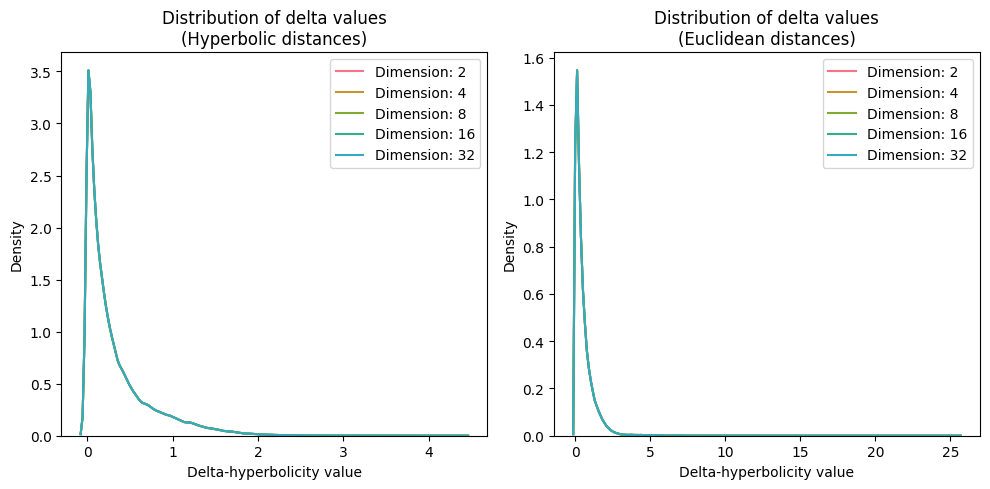

In [57]:
# Experiment 2: How does delta change with Distances?
from manify.curvature_estimation.delta_hyperbolicity import delta_full
dims = [2, 4, 8, 16, 32]

N = torch.distributions.MultivariateNormal(loc=torch.zeros(max(dims)), covariance_matrix=torch.eye(max(dims)))

# Get a single sample
x = N.sample(sample_shape=(N_SAMPLES,))
x_tangent = torch.hstack([torch.zeros(N_SAMPLES, 1), x])

h_deltas = []
e_deltas = []

# Create figure and axes first
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

for dim in dims:
    pm_d = ProductManifold(signature=[(CURVATURE, dim)])

    # Get the distance
    x_exp = pm.expmap(x_tangent[:, : dim + 1])
    h_dists = pm.pdist(x_exp)
    e_dists = torch.cdist(x_exp,x_exp)

    e_deltas.append(delta_full(e_dists))
    h_deltas.append(delta_full(h_dists))

# KDE plot
# Plot hyperbolic distances
for i, delta in enumerate(h_deltas):
    sns.kdeplot(delta.detach().cpu().numpy().flatten(), label=f"Dimension: {dims[i]}", color=colors[i], ax=ax1)
ax1.set_xlabel("Delta-hyperbolicity value")
ax1.set_ylabel("Density") 
ax1.set_title("Distribution of delta values\n(Hyperbolic distances)")
ax1.legend()

# Plot Euclidean distances
for i, delta in enumerate(e_deltas):
    sns.kdeplot(delta.detach().cpu().numpy().flatten(), label=f"Dimension: {dims[i]}", color=colors[i], ax=ax2)
ax2.set_xlabel("Delta-hyperbolicity value")
ax2.set_ylabel("Density")
ax2.set_title("Distribution of delta values\n(Euclidean distances)")
ax2.legend()

plt.tight_layout()
plt.show()